# Scale

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Enable inline plotting
%matplotlib inline

# Configuration
gpu_counts = [1, 2, 3, 4]
data_dir = Path('H100/spec_power_motif')
power_caps = [400,500,600,700,800,900,1000,1100,1200,1400,1700,2000]
performance_source = 'runtime'  # 'runtime' or 'throughput'


In [2]:
def calculate_metrics(benchmark, gpu_count, power_cap):
    """
    Calculate performance and energy consumption for a given configuration.
    performance_source == 'runtime': performance = 1 / execution_time
    performance_source == 'throughput': performance = throughput from throughput.csv
    Energy = average_power * execution_time (only for active GPUs)
    """
    csv_file = data_dir / benchmark / f"{power_cap}_{gpu_count}_gpu_metrics.csv"

    if not csv_file.exists():
        return None, None

    try:
        df = pd.read_csv(csv_file)

        if len(df) < 2:
            return None, None

        # Get execution time (prefer runtime.csv, fallback to GPU metrics timeline)
        execution_time = df['Time (s)'].iloc[-1] - df['Time (s)'].iloc[0]
        runtime_file = data_dir / benchmark / 'runtime.csv'
        if runtime_file.exists():
            df_runtime = pd.read_csv(runtime_file)
            match = df_runtime[(df_runtime['power_cap'] == power_cap) &
                              (df_runtime['gpu_count'] == gpu_count)]
            if len(match) > 0:
                execution_time = match.iloc[0]['runtime_seconds']

        metric_source = globals().get('performance_source', 'runtime')
        performance = None

        # For ML benchmarks, optionally use throughput as the performance metric.
        if metric_source == 'throughput':
            throughput_file = data_dir / benchmark / 'throughput.csv'
            if throughput_file.exists():
                df_throughput = pd.read_csv(throughput_file)
                throughput_cols = [c for c in df_throughput.columns if c.startswith('throughput_')]
                cap_col = 'total_gpu_cap' if 'total_gpu_cap' in df_throughput.columns else 'power_cap'

                if throughput_cols and cap_col in df_throughput.columns and 'gpu_count' in df_throughput.columns:
                    match = df_throughput[(df_throughput[cap_col] == power_cap) &
                                          (df_throughput['gpu_count'] == gpu_count)]
                    if len(match) > 0:
                        performance = match.iloc[0][throughput_cols[0]]

        # Default to runtime-based performance for non-ML benchmarks.
        if performance is None:
            performance = 1.0 / execution_time if execution_time > 0 else 0

        # Calculate energy: average_power * time (only for active GPUs)
        energy = 0.0
        for i in range(gpu_count):
            power_col = f'GPU{i}_Power (W)'
            if power_col in df.columns:
                avg_power = df[power_col].mean()
                energy += avg_power * execution_time

        return performance, energy

    except Exception as e:
        print(f"Error processing {csv_file}: {e}")
        return None, None


def collect_data():
    """Collect all data for the benchmarks."""
    data = {}
    
    for benchmark in benchmarks:
        data[benchmark] = {}
        
        for gpu_count in gpu_counts:
            performances = []
            energies = []
            valid_caps = []
            
            for power_cap in power_caps:
                perf, energy = calculate_metrics(benchmark, gpu_count, power_cap)
                
                if perf is not None and energy is not None:
                    performances.append(perf)
                    energies.append(energy)
                    valid_caps.append(power_cap)
            
            if performances:
                data[benchmark][gpu_count] = {
                    'power_caps': valid_caps,
                    'performance': np.array(performances),
                    'energy': np.array(energies)
                }
    
    return data

def normalize_data(data):
    """Normalize performance and energy to the baseline (highest power cap)."""
    normalized_data = {}
    
    for benchmark in data:
        normalized_data[benchmark] = {}
        
        for gpu_count in data[benchmark]:
            perf = data[benchmark][gpu_count]['performance']
            energy = data[benchmark][gpu_count]['energy']
            
            # Normalize to the highest power cap (last element when sorted)
            if len(perf) > 0:
                # Find the baseline (highest power cap)
                baseline_idx = np.argmax(data[benchmark][gpu_count]['power_caps'])
                baseline_perf = perf[baseline_idx]
                baseline_energy = energy[baseline_idx]
                
                normalized_data[benchmark][gpu_count] = {
                    'power_caps': data[benchmark][gpu_count]['power_caps'],
                    'performance': perf / baseline_perf,
                    'energy': energy / baseline_energy
                }
    
    return normalized_data


def plot_performance(benchmarks_to_plot):
    """
    Plot normalized performance as grouped bar charts.
    Higher is better.
    """
    metric_source = globals().get('performance_source', 'runtime')
    if metric_source == 'throughput':
        metric_label = 'Throughput'
    else:
        metric_label = 'Performance (1/Runtime)'

    for benchmark in benchmarks_to_plot:
        # Collect all power caps across all GPU counts for this benchmark
        all_caps = set()
        for gpu_count in gpu_counts:
            if gpu_count in data[benchmark]:
                all_caps.update(data[benchmark][gpu_count]['power_caps'])

        all_caps = sorted(list(all_caps))
        n_caps = len(all_caps)

        # Create grid layout (e.g., 4 columns)
        n_cols = 4
        n_rows = int(np.ceil(n_caps / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
        fig.suptitle(f'{benchmark.upper()} - Normalized Performance ({metric_label}, baseline: 1 GPU)', fontsize=16, fontweight='bold')

        # Flatten axes array for easier indexing
        axes = axes.flatten() if n_caps > 1 else [axes]

        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

        for cap_idx, power_cap in enumerate(all_caps):
            ax = axes[cap_idx]

            # Collect normalized performance for this power cap across all GPU counts
            x_pos = np.arange(len(gpu_counts))
            normalized_values = []

            # Get baseline (1 GPU performance for this power cap)
            baseline_perf = None
            if 1 in data[benchmark]:
                caps_1gpu = data[benchmark][1]['power_caps']
                perf_1gpu = data[benchmark][1]['performance']

                if power_cap in caps_1gpu:
                    cap_to_perf = dict(zip(caps_1gpu, perf_1gpu))
                    baseline_perf = cap_to_perf[power_cap]

            for gpu_count in gpu_counts:
                if gpu_count in data[benchmark] and baseline_perf is not None and baseline_perf > 0:
                    caps = data[benchmark][gpu_count]['power_caps']
                    perf = data[benchmark][gpu_count]['performance']

                    if power_cap in caps:
                        cap_to_perf = dict(zip(caps, perf))
                        perf_value = cap_to_perf[power_cap]
                        normalized_values.append(perf_value / baseline_perf if perf_value > 0 else 0)
                    else:
                        normalized_values.append(0)
                else:
                    normalized_values.append(0)

            # Plot bars
            bars = ax.bar(x_pos, normalized_values, color=colors, alpha=0.8)

            # Formatting
            ax.set_xticks(x_pos)
            ax.set_xticklabels([f'{g}GPU' for g in gpu_counts], fontsize=9)
            ax.set_title(f'{power_cap}W', fontsize=11, fontweight='bold')
            ax.set_ylabel('Normalized Performance', fontsize=9)
            ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)
            ax.grid(True, alpha=0.2, axis='y')

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.2f}',
                           ha='center', va='bottom', fontsize=8)

        # Hide empty subplots
        for idx in range(n_caps, len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.show()


def plot_energy(benchmarks_to_plot):
    """
    Plot normalized energy consumption as grouped bar charts.
    Normalized to 1 GPU case for each power cap.
    For each benchmark, create a subplot for each power cap case.
    Each subplot shows 4 bars representing different GPU counts.
    """
    for benchmark in benchmarks_to_plot:
        # Collect all power caps across all GPU counts for this benchmark
        all_caps = set()
        for gpu_count in gpu_counts:
            if gpu_count in data[benchmark]:
                all_caps.update(data[benchmark][gpu_count]['power_caps'])
        
        all_caps = sorted(list(all_caps))
        n_caps = len(all_caps)
        
        # Create grid layout (e.g., 4 columns)
        n_cols = 4
        n_rows = int(np.ceil(n_caps / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
        fig.suptitle(f'{benchmark.upper()} - Normalized Energy (baseline: 1 GPU)', fontsize=16, fontweight='bold')
        
        # Flatten axes array for easier indexing
        axes = axes.flatten() if n_caps > 1 else [axes]
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        
        for cap_idx, power_cap in enumerate(all_caps):
            ax = axes[cap_idx]
            
            # Collect energy data for this power cap across all GPU counts
            x_pos = np.arange(len(gpu_counts))
            normalized_energy_values = []
            
            # Get baseline (1 GPU energy for this power cap)
            baseline_energy = None
            if 1 in data[benchmark]:
                caps_1gpu = data[benchmark][1]['power_caps']
                energy_1gpu = data[benchmark][1]['energy']
                
                if power_cap in caps_1gpu:
                    cap_to_energy = dict(zip(caps_1gpu, energy_1gpu))
                    baseline_energy = cap_to_energy[power_cap]
            
            for gpu_count in gpu_counts:
                if gpu_count in data[benchmark] and baseline_energy is not None:
                    caps = data[benchmark][gpu_count]['power_caps']
                    energy = data[benchmark][gpu_count]['energy']
                    
                    # Find energy for this power cap
                    if power_cap in caps:
                        cap_to_energy = dict(zip(caps, energy))
                        normalized_energy_values.append(cap_to_energy[power_cap] / baseline_energy)
                    else:
                        normalized_energy_values.append(0)
                else:
                    normalized_energy_values.append(0)
            
            # Plot bars
            bars = ax.bar(x_pos, normalized_energy_values, color=colors, alpha=0.8)
            
            # Formatting
            ax.set_xticks(x_pos)
            ax.set_xticklabels([f'{g}GPU' for g in gpu_counts], fontsize=9)
            ax.set_title(f'{power_cap}W', fontsize=11, fontweight='bold')
            ax.set_ylabel('Normalized Energy', fontsize=9)
            # ax.set_ylim([0.7, 2])
            ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)
            ax.grid(True, alpha=0.2, axis='y')
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.2f}',
                           ha='center', va='bottom', fontsize=8)
        
        # Hide empty subplots
        for idx in range(n_caps, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()


def plot_edp(benchmarks_to_plot):
    """
    Plot normalized EDP (Energy-Delay Product) as grouped bar charts.
    EDP = Energy × Time
    Normalized to 1 GPU case for each power cap.
    For each benchmark, create a subplot for each power cap case.
    Each subplot shows 4 bars representing different GPU counts.
    """
    for benchmark in benchmarks_to_plot:
        # Collect all power caps across all GPU counts for this benchmark
        all_caps = set()
        for gpu_count in gpu_counts:
            if gpu_count in data[benchmark]:
                all_caps.update(data[benchmark][gpu_count]['power_caps'])
        
        all_caps = sorted(list(all_caps))
        n_caps = len(all_caps)
        
        # Create grid layout (e.g., 4 columns)
        n_cols = 4
        n_rows = int(np.ceil(n_caps / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
        fig.suptitle(f'{benchmark.upper()} - Normalized EDP (baseline: 1 GPU)', fontsize=16, fontweight='bold')
        
        # Flatten axes array for easier indexing
        axes = axes.flatten() if n_caps > 1 else [axes]
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        
        for cap_idx, power_cap in enumerate(all_caps):
            ax = axes[cap_idx]
            
            # Collect EDP data for this power cap across all GPU counts
            x_pos = np.arange(len(gpu_counts))
            normalized_edp_values = []
            
            # Get baseline (1 GPU EDP for this power cap)
            baseline_edp = None
            if 1 in data[benchmark]:
                caps_1gpu = data[benchmark][1]['power_caps']
                perf_1gpu = data[benchmark][1]['performance']
                energy_1gpu = data[benchmark][1]['energy']
                runtime_1gpu = 1.0 / perf_1gpu
                edp_1gpu = energy_1gpu * runtime_1gpu * runtime_1gpu
                
                if power_cap in caps_1gpu:
                    cap_to_edp = dict(zip(caps_1gpu, edp_1gpu))
                    baseline_edp = cap_to_edp[power_cap]
            
            for gpu_count in gpu_counts:
                if gpu_count in data[benchmark] and baseline_edp is not None:
                    caps = data[benchmark][gpu_count]['power_caps']
                    perf = data[benchmark][gpu_count]['performance']
                    energy = data[benchmark][gpu_count]['energy']
                    runtime = 1.0 / perf
                    edp = energy * runtime * runtime
                    
                    # Find EDP for this power cap
                    if power_cap in caps:
                        cap_to_edp = dict(zip(caps, edp))
                        normalized_edp_values.append(cap_to_edp[power_cap] / baseline_edp)
                    else:
                        normalized_edp_values.append(0)
                else:
                    normalized_edp_values.append(0)
            
            # Plot bars
            bars = ax.bar(x_pos, normalized_edp_values, color=colors, alpha=0.8)
            
            # Formatting
            ax.set_xticks(x_pos)
            ax.set_xticklabels([f'{g}GPU' for g in gpu_counts], fontsize=9)
            ax.set_title(f'{power_cap}W', fontsize=11, fontweight='bold')
            ax.set_ylabel('Normalized EDP', fontsize=9)
            # ax.set_ylim([0, 1.5])
            ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)
            ax.grid(True, alpha=0.2, axis='y')
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.2f}',
                           ha='center', va='bottom', fontsize=8)
        
        # Hide empty subplots
        for idx in range(n_caps, len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()


def plot_combined_metrics(benchmarks_to_plot):

    for benchmark in benchmarks_to_plot:
        # Collect all power caps across all GPU counts for this benchmark
        all_caps = set()
        for gpu_count in gpu_counts:
            if gpu_count in data[benchmark]:
                all_caps.update(data[benchmark][gpu_count]['power_caps'])
        
        all_caps = sorted(list(all_caps))
        n_caps = len(all_caps)
        
        # Create grid layout: 3 rows (metrics) × n_caps columns (power caps)
        n_cols = n_caps
        n_rows = 3
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
        # Get max power info (4 GPUs @ 2000W)
        max_power_info = ""
        if 4 in data[benchmark] and 2000 in data[benchmark][4]['power_caps']:
            csv_file = data_dir / benchmark / f"2000_4_gpu_metrics.csv"
            if csv_file.exists():
                df = pd.read_csv(csv_file)
                # Find max power across all GPUs and all time steps
                max_gpu_power = 0
                for i in range(4):
                    power_col = f'GPU{i}_Power (W)'
                    if power_col in df.columns:
                        gpu_max = df[power_col].max()
                        max_gpu_power = max(max_gpu_power, gpu_max)
            max_power_info = f" | Max Power per GPU: {max_gpu_power:.1f}W ({max_gpu_power*4:.0f}W total)"

        fig.suptitle(f'{benchmark.upper()}{max_power_info}', 
                    fontsize=16, fontweight='bold', y=1.02)


        
        # Handle single column case
        if n_caps == 1:
            axes = axes.reshape(-1, 1)
        
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        metric_names = ['Runtime', 'Energy', 'EDP']
        
        for cap_idx, power_cap in enumerate(all_caps):
            # Get baseline values (1 GPU) for this power cap
            baseline_runtime = None
            baseline_energy = None
            baseline_edp = None
            
            if 1 in data[benchmark]:
                caps_1gpu = data[benchmark][1]['power_caps']
                perf_1gpu = data[benchmark][1]['performance']
                energy_1gpu = data[benchmark][1]['energy']
                runtime_1gpu = 1.0 / perf_1gpu
                edp_1gpu = energy_1gpu * runtime_1gpu
                
                if power_cap in caps_1gpu:
                    idx = caps_1gpu.index(power_cap)
                    baseline_runtime = runtime_1gpu[idx]
                    baseline_energy = energy_1gpu[idx]
                    baseline_edp = edp_1gpu[idx]
            
            # Collect data for all GPU counts at this power cap
            x_pos = np.arange(len(gpu_counts))
            runtime_values = []
            energy_values = []
            edp_values = []
            
            for gpu_count in gpu_counts:
                if gpu_count in data[benchmark]:
                    caps = data[benchmark][gpu_count]['power_caps']
                    perf = data[benchmark][gpu_count]['performance']
                    energy = data[benchmark][gpu_count]['energy']
                    runtime = 1.0 / perf
                    edp = energy * runtime
                    
                    if power_cap in caps:
                        idx = caps.index(power_cap)
                        if baseline_runtime is not None:
                            runtime_values.append(runtime[idx] / baseline_runtime)
                            energy_values.append(energy[idx] / baseline_energy)
                            edp_values.append(edp[idx] / baseline_edp)
                        else:
                            runtime_values.append(0)
                            energy_values.append(0)
                            edp_values.append(0)
                    else:
                        runtime_values.append(0)
                        energy_values.append(0)
                        edp_values.append(0)
                else:
                    runtime_values.append(0)
                    energy_values.append(0)
                    edp_values.append(0)
            
            # Plot all three metrics for this power cap
            metrics_data = [runtime_values, energy_values, edp_values]
            
            for metric_idx, (metric_name, metric_values) in enumerate(zip(metric_names, metrics_data)):
                ax = axes[metric_idx, cap_idx]
                
                # Store actual values before clipping
                actual_values = metric_values.copy()
                
                # Clip values for display
                clipped_values = [min(v, 5) if v > 0 else 0 for v in metric_values]
                
                # Plot bars with clipped values
                bars = ax.bar(x_pos, clipped_values, color=colors, alpha=0.8)
                
                # Formatting
                ax.set_xticks(x_pos)
                ax.set_xticklabels([f'{g}' for g in gpu_counts], fontsize=9)
                
                # Only show xlabel on bottom row
                if metric_idx == 2:
                    ax.set_xlabel('# GPUs', fontsize=12)
                
                # Only show power cap title on top row
                if metric_idx == 0:
                    ax.set_title(f'{power_cap}W', fontsize=11, fontweight='bold')
                
                # Only show ylabel on leftmost column
                if cap_idx == 0:
                    ax.set_ylabel(f'Norm. {metric_name}', fontsize=12)
                
                # ax.set_ylim([0, 1.1])
                ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)
                ax.grid(True, alpha=0.2, axis='y')
                
                # Add value labels on bars showing actual values
                for i, bar in enumerate(bars):
                    actual_val = actual_values[i]
                    if actual_val > 0:
                        # Position at top of clipped bar
                        y_pos = min(actual_val, 5)
                        ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                               f'{actual_val:.2f}',
                               ha='center', va='bottom', fontsize=12)
        
        plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.95, bottom=0.05)
        plt.show()


In [3]:
benchmarks = ['pot3d','minisweep','lbm', 'cloverleaf', 'tealeaf','miniweather']
performance_source = 'runtime'
# benchmarks = ['minisweep','lbm', 'cloverleaf', 'tealeaf']
data = collect_data()
normalized_data = normalize_data(data)


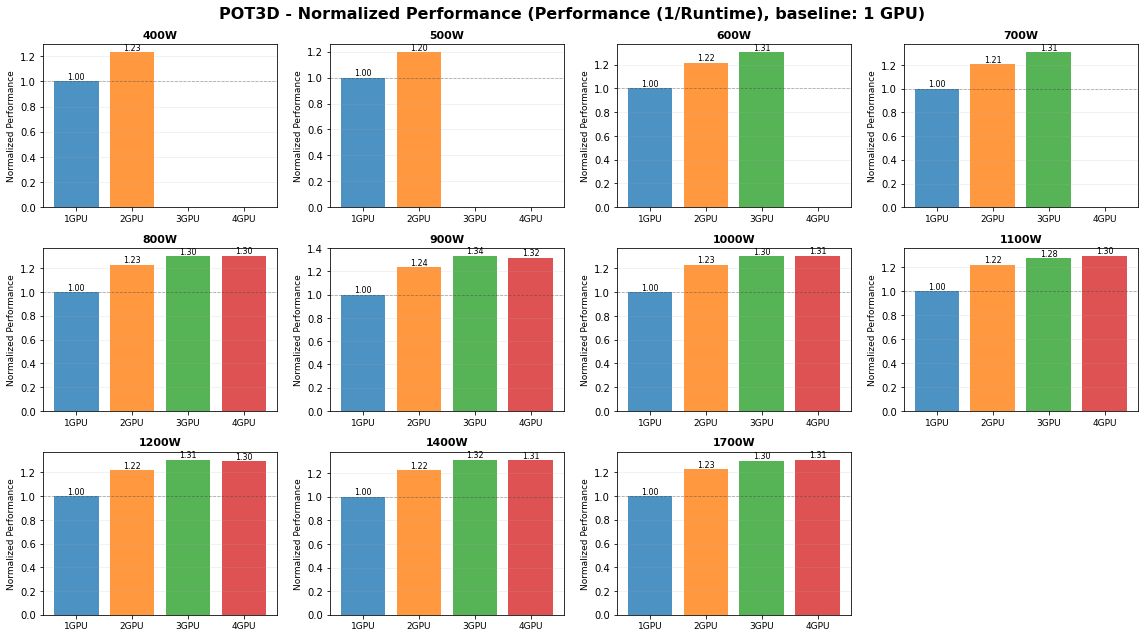

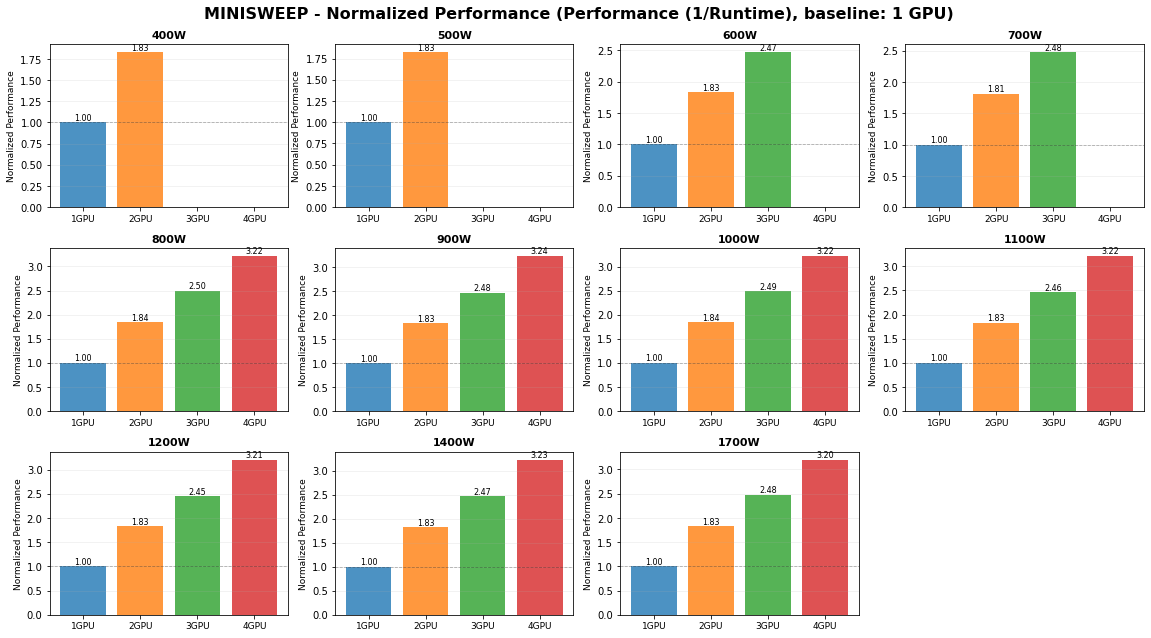

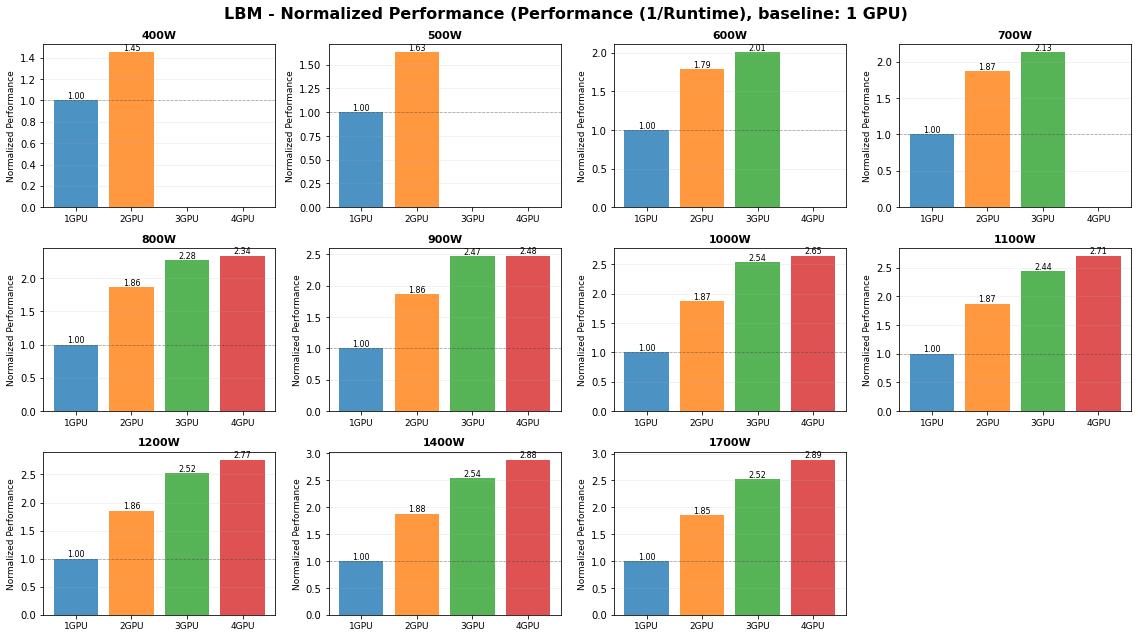

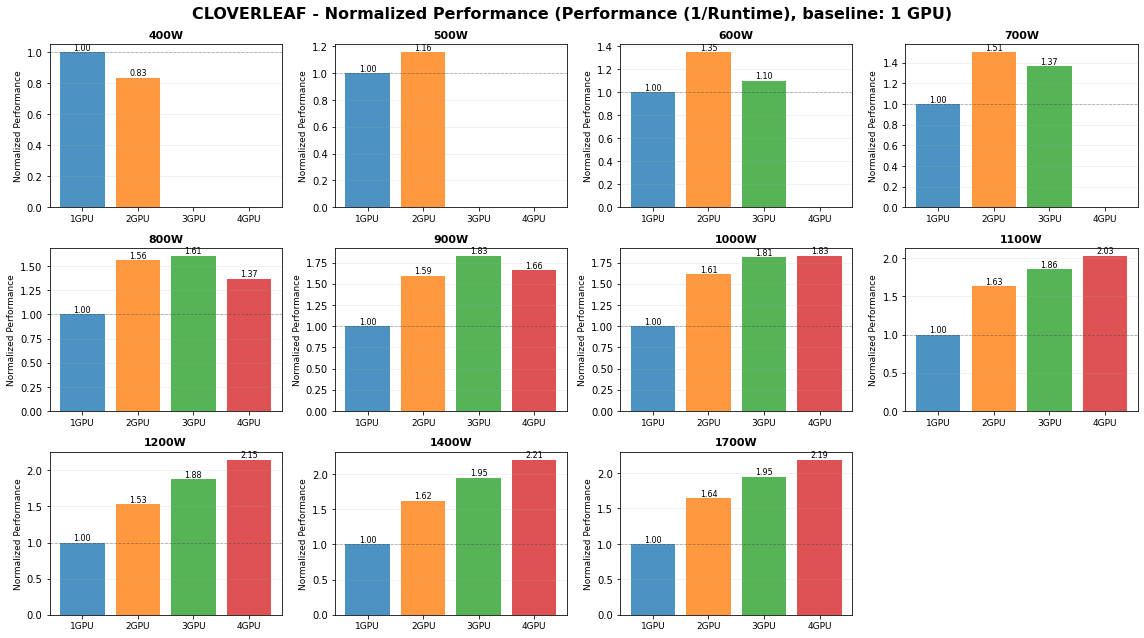

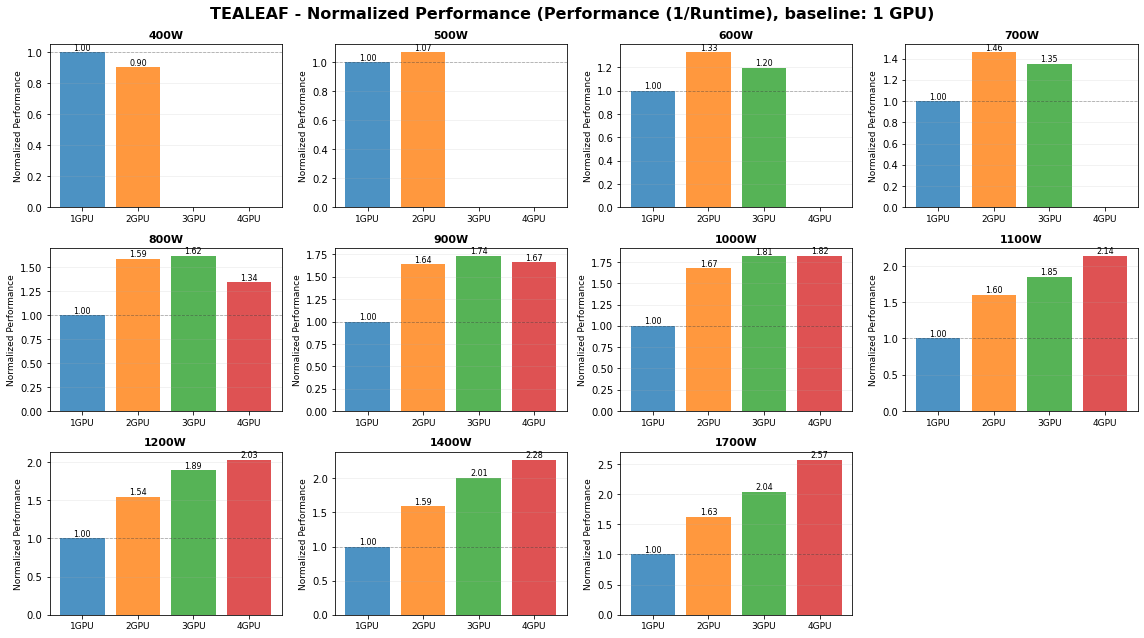

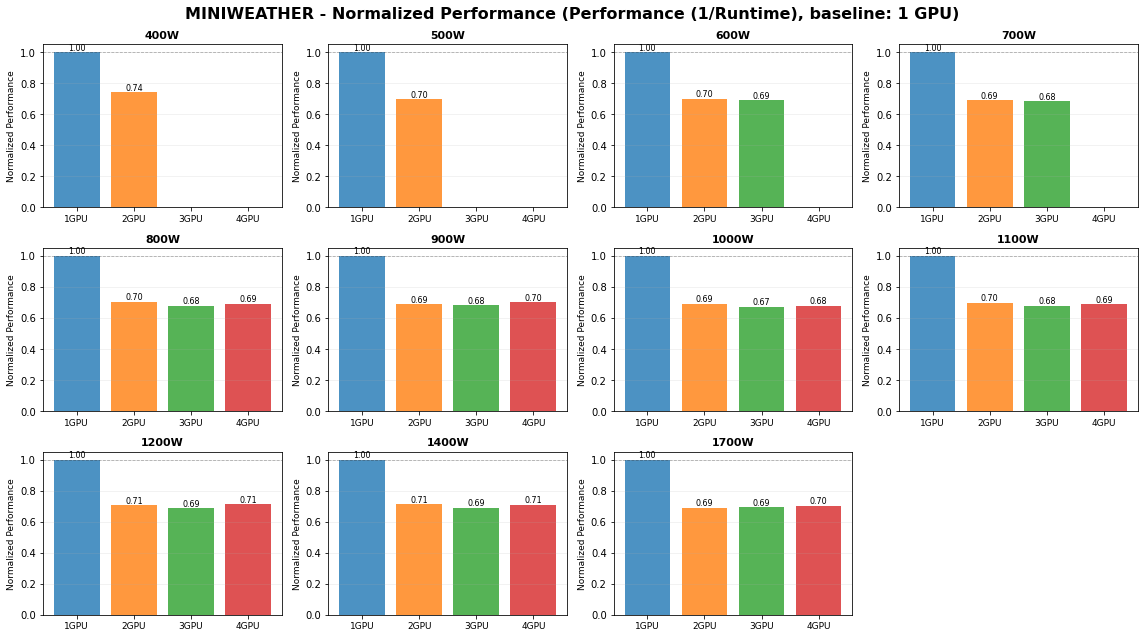

In [4]:
plot_performance(benchmarks)

In [5]:
# ML benchmarks
data_dir = Path('H100/ml_power_motif')
benchmarks = ['bert', 'gpt2', 'resnet50']
performance_source = 'throughput'
data = collect_data()
normalized_data = normalize_data(data)


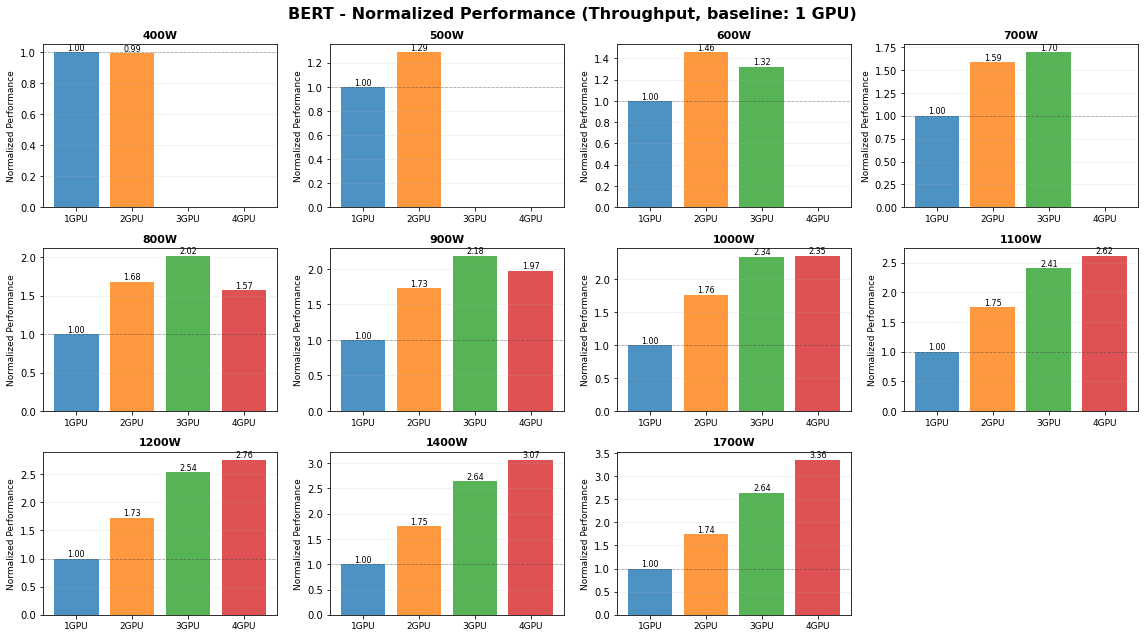

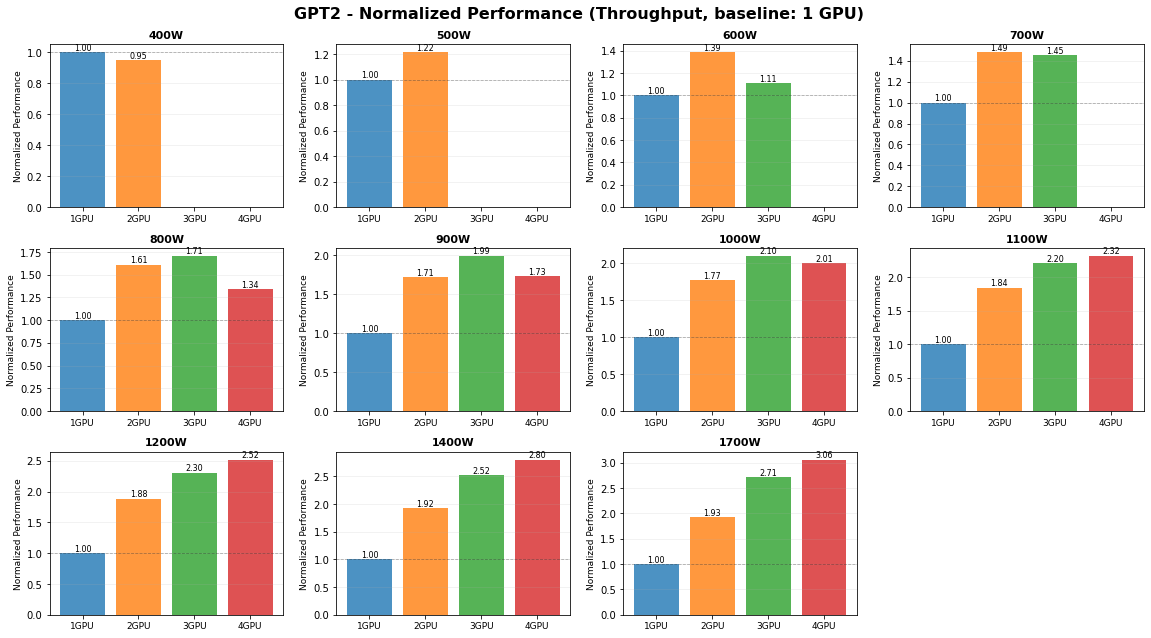

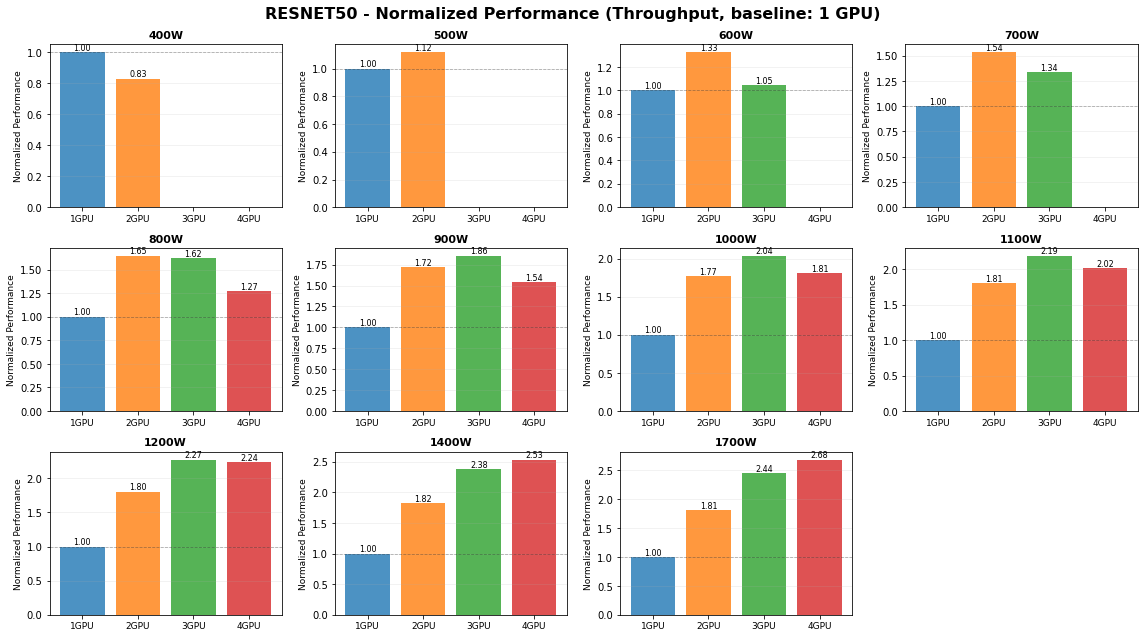

In [6]:
plot_performance(benchmarks)

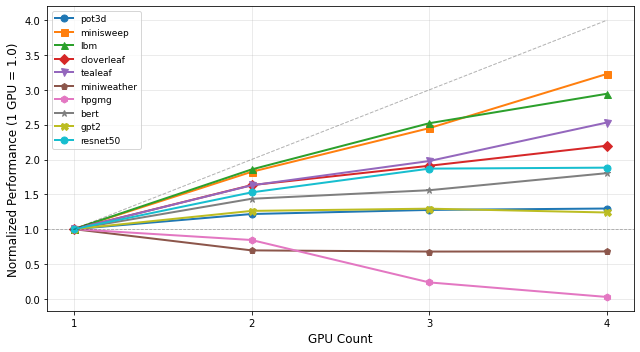

In [30]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Energy & EDP at 1800W power cap for all applications (1-4 GPUs)
power_cap = 1800
gpu_counts = [1, 2, 3, 4]

# Both SPEC and ML benchmarks
spec_benchmarks = ['pot3d', 'minisweep', 'lbm', 'cloverleaf', 'tealeaf', 'miniweather','hpgmg']
ml_benchmarks = ['bert', 'gpt2', 'resnet50']

all_configs = [
    (Path('H100/spec_power_motif'), spec_benchmarks),
    (Path('H100/ml_power_motif'), ml_benchmarks),
]

energy_results = {}
runtime_results = {}

for base_dir, benchmarks in all_configs:
    for bench in benchmarks:
        energy_results[bench] = {}
        runtime_results[bench] = {}
        for gpu_count in gpu_counts:
            csv_file = base_dir / bench / f"{power_cap}_{gpu_count}_gpu_metrics.csv"
            if not csv_file.exists():
                continue

            df = pd.read_csv(csv_file)

            # Get execution time from runtime.csv if available, else from GPU metrics timeline
            execution_time = df['Time (s)'].iloc[-1] - df['Time (s)'].iloc[0]
            runtime_file = base_dir / bench / 'runtime.csv'
            if runtime_file.exists():
                df_runtime = pd.read_csv(runtime_file)
                match = df_runtime[(df_runtime['power_cap'] == power_cap) &
                                   (df_runtime['gpu_count'] == gpu_count)]
                if len(match) > 0:
                    execution_time = match.iloc[0]['runtime_seconds']

            # Energy = sum of (avg_power_per_gpu * execution_time) across all active GPUs
            total_energy = 0.0
            for i in range(gpu_count):
                power_col = f'GPU{i}_Power (W)'
                if power_col in df.columns:
                    avg_power = df[power_col].mean()
                    total_energy += avg_power * execution_time

            energy_results[bench][gpu_count] = total_energy
            runtime_results[bench][gpu_count] = execution_time

# Build DataFrames
energy_df = pd.DataFrame(energy_results).T
energy_df.columns = [f'{g} GPU' for g in energy_df.columns]
energy_df.index.name = 'Application'

runtime_df = pd.DataFrame(runtime_results).T
runtime_df.columns = [f'{g} GPU' for g in runtime_df.columns]

# EDP = Energy * Runtime
edp_df = energy_df * runtime_df

# Normalized performance (speedup) = runtime_1GPU / runtime_NGPU
normalized_perf_df = runtime_df.rdiv(runtime_df['1 GPU'], axis=0).round(3)

# Normalize energy and EDP to each app's 1 GPU case
normalized_energy_df = energy_df.div(energy_df['1 GPU'], axis=0).round(3)
normalized_edp_df = edp_df.div(edp_df['1 GPU'], axis=0).round(3)

# Commented out: table displays
# print("Normalized Energy Consumption at 1800W Power Cap (baseline: 1 GPU per app)")
# print("=" * 70)
# display(normalized_energy_df)

# print("\nNormalized EDP at 1800W Power Cap (baseline: 1 GPU per app)")
# print("=" * 70)
# display(normalized_edp_df)

# print("\nNormalized Performance (Speedup) at 1800W Power Cap (baseline: 1 GPU per app)")
# print("=" * 70)
# display(normalized_perf_df)

# Commented out: bar chart plots
# fig, axes = plt.subplots(3, 1, figsize=(9, 12))
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
#
# for ax, norm_df, title, ylabel in zip(
#     axes,
#     [normalized_energy_df, normalized_edp_df, normalized_perf_df],
#     ['Normalized Energy Consumption at 1800W Power Cap (1-4 GPUs)',
#      'Normalized EDP at 1800W Power Cap (1-4 GPUs)',
#      'Normalized Performance (Speedup) at 1800W Power Cap (1-4 GPUs)'],
#     ['Normalized Energy (1 GPU = 1.0)',
#      'Normalized EDP (1 GPU = 1.0)',
#      'Normalized Performance (1 GPU = 1.0)']
# ):
#     x = np.arange(len(norm_df))
#     width = 0.2
#
#     for i, col in enumerate(norm_df.columns):
#         bars = ax.bar(x + i * width, norm_df[col], width, label=col, color=colors[i], alpha=0.8)
#         for bar in bars:
#             height = bar.get_height()
#             if height > 0:
#                 ax.text(bar.get_x() + bar.get_width()/2., height,
#                         f'{height:.2f}', ha='center', va='bottom', fontsize=7)
#
#     ax.set_xlabel('Application')
#     ax.set_ylabel(ylabel)
#     ax.set_title(title)
#     ax.set_xticks(x + 1.5 * width)
#     ax.set_xticklabels(norm_df.index, rotation=45, ha='right')
#     ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)
#     ax.legend()
#     ax.grid(True, alpha=0.2, axis='y')
#
# plt.tight_layout()
# plt.show()

# Line plot: Normalized Performance per application (x=GPU count, y=speedup, baseline=1 GPU)
fig, ax = plt.subplots(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*', 'X']

for i, app in enumerate(normalized_perf_df.index):
    gpu_vals = [int(c.split()[0]) for c in normalized_perf_df.columns]
    perf_vals = normalized_perf_df.loc[app].values
    ax.plot(gpu_vals, perf_vals, marker=markers[i % len(markers)], label=app, linewidth=2, markersize=7)

ax.plot(gpu_vals, gpu_vals, 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('GPU Count', fontsize=12)
ax.set_ylabel('Normalized Performance (1 GPU = 1.0)', fontsize=12)
# ax.set_title('Normalized Performance at 1800W Power Cap', fontsize=14)
ax.set_xticks(gpu_vals)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)

plt.tight_layout()
plt.savefig('./fig/performance_vs_gpu_count.png', dpi=300)
plt.show()


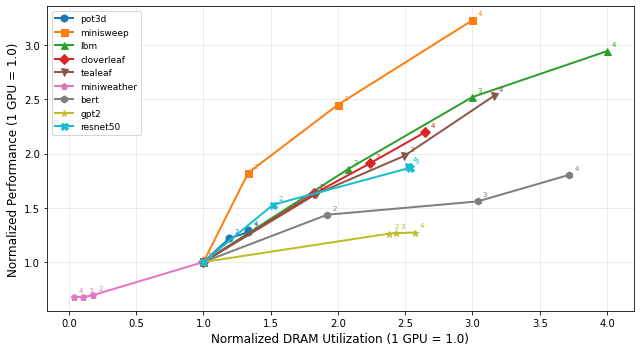

In [31]:
# Parse edp_metrics.txt for DRAM utilization and performance
edp_metrics_file = Path('H100/edp_metrics.txt')
edp_text = edp_metrics_file.read_text()

import re

# Parse each benchmark section without splitting away the closing ===== line.
section_pattern = re.compile(
    r'^=====\s+(?P<name>\S+)\s+=====\n(?P<body>.*?)(?=^=====\s+\S+\s+=====|\Z)',
    re.M | re.S,
)

dram_results = {}
perf_results = {}

for match in section_pattern.finditer(edp_text.strip()):
    bench_name = match.group('name').split('/')[-1]
    body_lines = match.group('body').strip().splitlines()

    dram_results[bench_name] = {}
    perf_results[bench_name] = {}
    for line in body_lines:
        if not line.strip() or line.startswith('cap=') or line.startswith('gpu_count'):
            continue
        parts = line.split('\t')
        if len(parts) >= 4:
            gpu_count = int(parts[0])
            performance = float(parts[1])
            dram_sum = float(parts[3])
            dram_results[bench_name][gpu_count] = dram_sum
            perf_results[bench_name][gpu_count] = performance

if not perf_results:
    raise ValueError(f'No benchmark sections were parsed from {edp_metrics_file}')

# Build DataFrames with explicit column order
gpu_cols_int = [1, 2, 3, 4]
col_names = [f'{g} GPU' for g in gpu_cols_int]

dram_df = pd.DataFrame(dram_results).T.reindex(columns=gpu_cols_int)
dram_df.columns = col_names

perf_from_edp_df = pd.DataFrame(perf_results).T.reindex(columns=gpu_cols_int)
perf_from_edp_df.columns = col_names

# Performance is runtime, so normalized perf = runtime_1GPU / runtime_NGPU
norm_perf = perf_from_edp_df.rdiv(perf_from_edp_df['1 GPU'], axis=0).round(3)
norm_dram = dram_df.div(dram_df['1 GPU'], axis=0).round(3)

# Filter to target benchmarks
target_benchmarks = ['pot3d', 'minisweep', 'lbm', 'cloverleaf', 'tealeaf', 'miniweather',
                     'bert', 'gpt2', 'resnet50']
norm_perf = norm_perf.loc[norm_perf.index.isin(target_benchmarks)]
norm_dram = norm_dram.loc[norm_dram.index.isin(target_benchmarks)]

if norm_perf.empty:
    raise ValueError(f'No target benchmarks found. Parsed benchmarks: {sorted(perf_results)}')

# Plot: x = normalized DRAM utilization, y = normalized performance
fig, ax = plt.subplots(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*', 'X']
colors_list = plt.cm.tab10(np.linspace(0, 1, len(norm_perf)))

for i, app in enumerate(norm_perf.index):
    x_vals = norm_dram.loc[app].values
    y_vals = norm_perf.loc[app].values
    ax.plot(x_vals, y_vals, marker=markers[i % len(markers)], label=app,
            linewidth=2, markersize=7, color=colors_list[i])
    # Annotate each point with GPU count
    for j, col in enumerate(col_names):
        gpu_n = col.split()[0]
        ax.annotate(f'{gpu_n}', (x_vals[j], y_vals[j]), textcoords='offset points',
                    xytext=(5, 5), fontsize=7, color=colors_list[i])

ax.set_xlabel('Normalized DRAM Utilization (1 GPU = 1.0)', fontsize=12)
ax.set_ylabel('Normalized Performance (1 GPU = 1.0)', fontsize=12)
# ax.set_title('DRAM Utilization vs Performance at 1800W Power Cap', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./fig/dram_utilization_vs_performance.png', dpi=300)
plt.show()

